In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import constantes as const

In [3]:
# Esto es para que se actualicen los cambios en los archivos importados
%load_ext autoreload
%autoreload 2

In [33]:
from utils.data import DataManager

data_manager = DataManager()
data_manager.preparar_conjuntos()

X_train, y_train, weights_train = data_manager.get_train_data()
X, y = data_manager.get_X_y()
test = data_manager.get_test()
weights = data_manager.get_weights()

In [48]:
X_test, y_test, weights_test = data_manager.get_test_data()

In [43]:
from utils.preprocess import DataPreprocessor
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve

data_preprocessor = DataPreprocessor()

model = RandomForestClassifier(random_state=const.RANDOM_STATE, class_weight='balanced', n_jobs=12, n_estimators=936, max_depth=40, min_samples_split=5, min_samples_leaf=4, max_features='sqrt')

full_pipeline = Pipeline(steps=[('preprocessor', data_preprocessor),
                                ('classifier', model)])

#y_probas_forest = cross_val_predict(full_pipeline, X_train, y_train, cv=3, method="predict_proba")

#y_scores_forest = y_probas_forest[:, 1]
#fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train,y_scores_forest)


In [46]:
full_pipeline.fit(X_train, y_train, classifier__sample_weight=weights_train)

KeyboardInterrupt: 

In [ ]:
y_pred = y

In [82]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
from utils.HiggsBosonCompetition_AMSMetric_rev1 import ams_scorer
import sklearn

sklearn.set_config(enable_metadata_routing=True)
ams_custom_score = make_scorer(ams_scorer, greater_is_better=True, needs_proba=False).set_score_request(sample_weight=True)

data_preprocessor = DataPreprocessor()
model = RandomForestClassifier(class_weight='balanced', n_jobs=12).set_fit_request(sample_weight=True)

pipeline = Pipeline([
    ('preprocessor', data_preprocessor),
    ('classifier', model)
])

param_dist = {
        'classifier__n_estimators': range(200),
        'classifier__max_depth': range(15),
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist, n_iter=30,
    cv=2,
    verbose=2,
    random_state=const.RANDOM_STATE,
    scoring="neg_log_loss",
    n_jobs=-1)

random_search.fit(X_train, y_train, sample_weight=weights_train)

print("Mejores parámetros:", random_search.best_params_)
sklearn.set_config(enable_metadata_routing=False)


Fitting 2 folds for each of 30 candidates, totalling 60 fits


/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.9/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:547: FitFailedWarning: 
6 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniconda/base/envs/ml/lib/python3.9/site-packages/sklearn/model_selecti

Mejores parámetros: {'classifier__n_estimators': 94, 'classifier__max_depth': 14}


In [83]:
print("Mejor puntaje AMS:", random_search.best_score_)
print("Mejores parámetros:", random_search.best_params_)

Mejor puntaje AMS: -1.022219310186396
Mejores parámetros: {'classifier__n_estimators': 94, 'classifier__max_depth': 14}
[CV] END classifier__max_depth=12, classifier__n_estimators=196; total time= 1.6min
[CV] END classifier__max_depth=8, classifier__n_estimators=145; total time=  48.8s
[CV] END classifier__max_depth=13, classifier__n_estimators=16; total time=  13.7s
[CV] END classifier__max_depth=0, classifier__n_estimators=22; total time=   1.8s
[CV] END classifier__max_depth=6, classifier__n_estimators=25; total time=   9.2s
[CV] END classifier__max_depth=0, classifier__n_estimators=136; total time=   1.8s
[CV] END classifier__max_depth=14, classifier__n_estimators=94; total time=  46.9s
[CV] END classifier__max_depth=2, classifier__n_estimators=103; total time=  12.3s
[CV] END classifier__max_depth=10, classifier__n_estimators=55; total time=  27.6s
[CV] END classifier__max_depth=10, classifier__n_estimators=105; total time=  45.2s
[CV] END classifier__max_depth=12, classifier__n_e

In [32]:
from utils.comet_experiments import exp_tune_classifier
exp_eval_classifier("Random Forest", random_search, X_test, y_test, weights_test, "tZzHrgZeB2lMeZSSnDvSFUAIV")
exp_tune_classifier("Random Forest", random_search, "tZzHrgZeB2lMeZSSnDvSFUAIV")


COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/xqft/proyecto-1-taa/045d656a75ca42248cb9ea781fb0fbe7



signal = 2.5422141046999602
background = 14.165407250307801
[0 0 0 ... 1 1 1]
[0.98449013 0.98786611 0.99375862 ... 0.73999802 0.81048579 0.98151859]
[0.0038984  0.00712145 0.00871579 ... 0.99993692 0.99993706 0.99993716]
[0.3394     0.33938679 0.33937357 ... 0.         0.         1.        ]
[1.         0.99994107 0.99988214 ... 0.         0.         0.        ]


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Evaluate Random Forest
COMET INFO:     url                   : https://www.comet.com/xqft/proyecto-1-taa/045d656a75ca42248cb9ea781fb0fbe7
COMET INFO:   Metrics:
COMET INFO:     AMS : 0.5084566430144426
COMET INFO:   Others:
COMET INFO:     Name : Evaluate Random Forest
COMET INFO:   Uploads:
COMET INFO:     conda-environment-definition : 1
COMET INFO:     conda-info                   : 1
COMET INFO:     conda-specification          : 1
COMET INFO:     curve                        : 4
COMET INFO:     environment details          : 1
COMET INFO:     filename                     : 1
COMET INFO:     git metadata                 : 1
COMET INFO:     git-pa

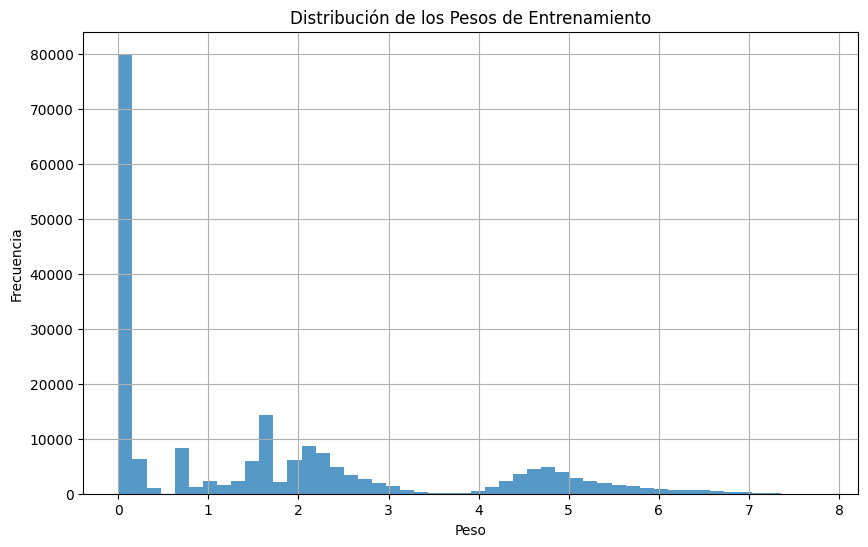

Estadísticas de pesos:
Mínimo: 0.00150187015894
Máximo: 7.82196070702
Media: 1.646829127004262
Mediana: 1.15105421442
Desviación estándar: 1.8764018031941383


In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(weights_train, bins=50, alpha=0.75)
plt.title('Distribución de los Pesos de Entrenamiento')
plt.xlabel('Peso')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

print("Estadísticas de pesos:")
print("Mínimo:", weights_train.min())
print("Máximo:", weights_train.max())
print("Media:", weights_train.mean())
print("Mediana:", weights_train.median())
print("Desviación estándar:", weights_train.std())

In [ ]:
print(y_probas_forest[:10])

[[0.54518634 0.45481366]
 [0.31536679 0.68463321]
 [0.98951811 0.01048189]
 [0.35432103 0.64567897]
 [0.02725138 0.97274862]
 [0.87128391 0.12871609]
 [0.42881486 0.57118514]
 [0.99009531 0.00990469]
 [0.34728471 0.65271529]
 [0.36112807 0.63887193]]


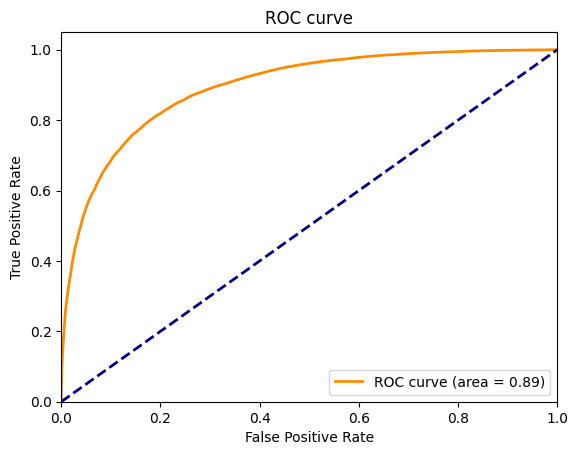

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = random_search.best_estimator_.predict_proba(X_test)[:, 1]

fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_test, y_prob)

roc_auc = auc(fpr_forest, tpr_forest)

plt.figure()
plt.plot(fpr_forest, tpr_forest, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.legend(loc="lower right")
plt.show()


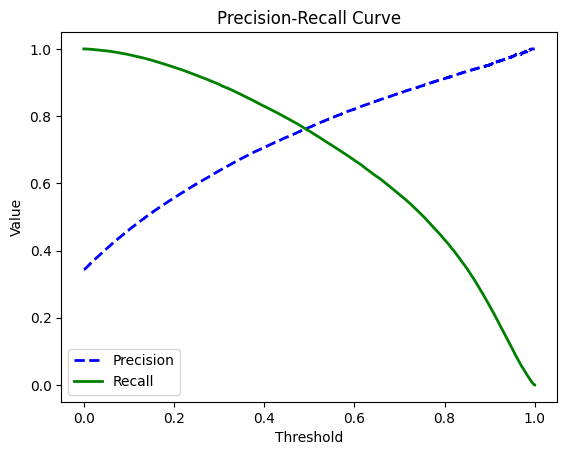

In [36]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from utils.metrics import MetricsManager

y_scores_forest = y_probas_forest[:, 1]


MetricsManager.plot_precision_recall_vs_threshold(y_train, y_scores_forest)

In [47]:
from sklearn.metrics import classification_report

full_pipeline.fit(X_train, y_train, classifier__sample_weight=weights_train)
y_probas = full_pipeline.predict_proba(X_test)
y_scores = y_probas[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)


best_threshold = MetricsManager.get_best_threshold(precision, recall, thresholds)

y_pred_optimal = (y_scores >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_optimal))


              precision    recall  f1-score   support

           0       0.88      0.84      0.86     33030
           1       0.72      0.79      0.75     16970

    accuracy                           0.82     50000
   macro avg       0.80      0.81      0.81     50000
weighted avg       0.83      0.82      0.83     50000



In [56]:
print(best_threshold)


0.1


In [52]:
from utils.HiggsBosonCompetition_AMSMetric_rev1 import ams_scorer
ams_scorer(y_test, full_pipeline.predict(X_test) > 0.15, weights_test)

signal = 54.832179811140406
background = 1299.2898532074414


1.5049695633829099

ValueError: x and y must be the same size

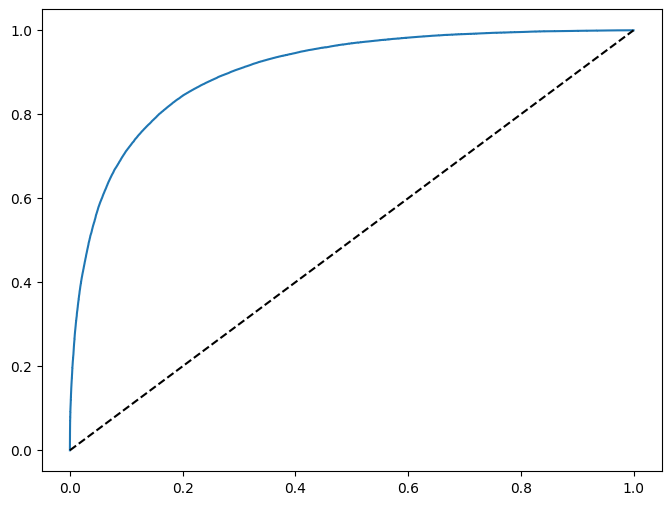

In [105]:
from sklearn.metrics import auc

y_probas_forest = cross_val_predict(random_search.best_estimator_, X_train, y_train, cv=3, method="predict_proba")
y_scores_forest = y_probas_forest[:, 1]
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train, y_scores_forest)

J = tpr_forest - fpr_forest
idx = np.argmax(J)
best_thresh = thresholds_forest[idx]

plt.figure(figsize=(8, 6))
plt.plot(fpr_forest, tpr_forest, label='ROC curve (area = %0.2f)' % auc(fpr_forest, tpr_forest))
plt.plot([0, 1], [0, 1], 'k--')
plt.scatter(fpr_forest[idx], tpr_forest)

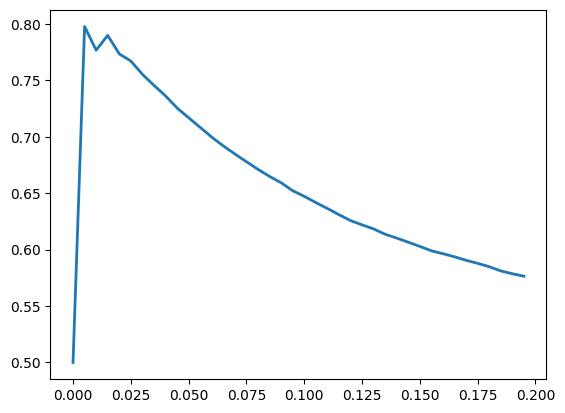

In [102]:
import matplotlib.pyplot as plt

plt.plot(thresholds_range, scores, linewidth=2)


In [106]:
y_test_proba = random_search.best_estimator_.predict_proba(test)
y_test_scores = y_test_proba[:, 1]
y_test_pred = (y_test_scores >= best_thresh).astype(int)

submission_df = pd.DataFrame({
    "EventId": test["EventId"],
    "Class": y_test_pred,
    "Probability": y_test_scores
})

submission_df = submission_df.sort_values(by='Probability', ascending=False)

submission_df['RankOrder'] = range(1, len(submission_df) + 1)
submission_df['Class'] = submission_df['Class'].map({1: 's', 0: 'b'})

submission_df = submission_df[['EventId', 'Class', 'RankOrder']]

submission_df.to_csv("submission.csv", index=False)

In [ ]:
!kaggle competitions submit -c higgs-boson -f submission.csv -m "Second submission"

Successfully submitted to Higgs Boson Machine Learning Challenge


  0%|          | 0.00/8.81M [00:00<?, ?B/s]
  0%|          | 16.0k/8.81M [00:00<02:10, 70.6kB/s]
  6%|▌         | 544k/8.81M [00:00<00:04, 2.06MB/s] 
 13%|█▎        | 1.17M/8.81M [00:00<00:02, 3.65MB/s]
 18%|█▊        | 1.62M/8.81M [00:00<00:02, 3.75MB/s]
 23%|██▎       | 2.05M/8.81M [00:00<00:01, 3.82MB/s]
 28%|██▊       | 2.45M/8.81M [00:01<00:03, 2.21MB/s]
 31%|███▏      | 2.77M/8.81M [00:01<00:03, 2.04MB/s]
 34%|███▍      | 3.03M/8.81M [00:01<00:02, 2.02MB/s]
 39%|███▊      | 3.41M/8.81M [00:01<00:02, 2.40MB/s]
 43%|████▎     | 3.80M/8.81M [00:01<00:01, 2.75MB/s]
 48%|████▊     | 4.19M/8.81M [00:01<00:01, 3.04MB/s]
 52%|█████▏    | 4.56M/8.81M [00:01<00:01, 3.26MB/s]
 56%|█████▌    | 4.95M/8.81M [00:01<00:01, 3.45MB/s]
 60%|██████    | 5.33M/8.81M [00:01<00:01, 3.57MB/s]
 65%|██████▍   | 5.72M/8.81M [00:02<00:00, 3.68MB/s]
 69%|██████▉   | 6.09M/8.81M [00:02<00:00, 3.75MB/s]
 73%|███████▎  | 6.47M/8.81M [00:02<00:00, 3.79MB/s]
 78%|███████▊  | 6.84M/8.81M [00:02<00:00, 3.82MB/s]
 

In [ ]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=3, shuffle=True, random_state=const.RANDOM_STATE)

y_probas_forest = np.array([])

for train_index, test_index in kf.split(X_train):

    X_train_fold, X_test_fold = X_train.iloc[train_index], X_train.iloc[test_index]
    y_train_fold, y_test_fold = y_train[train_index], y_train[test_index]
    weights_train_fold = weights_train.iloc[train_index]
    
    full_pipeline.fit(X_train_fold, y_train_fold, classifier__sample_weight=weights_train_fold)

    y_probas_fold = full_pipeline.predict_proba(X_test_fold)[:, 1]
    
    y_probas_forest = np.concatenate((y_probas_forest, y_probas_fold))

fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train, y_probas_forest)


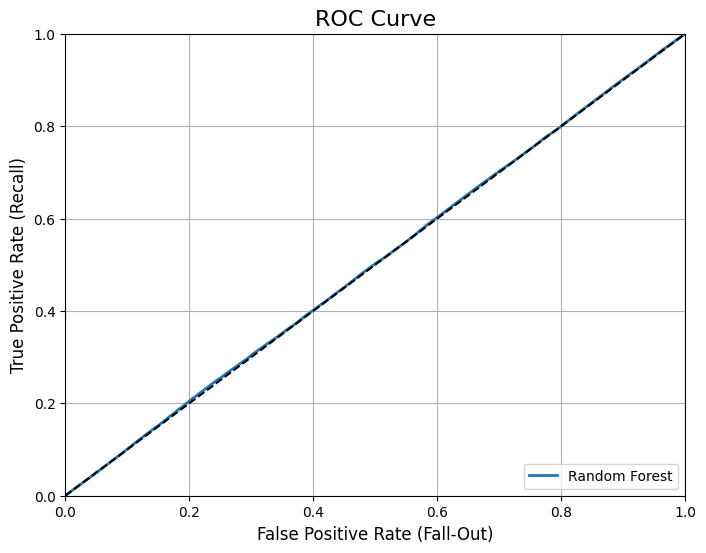

In [ ]:
MetricsManager.plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right")
plt.show()

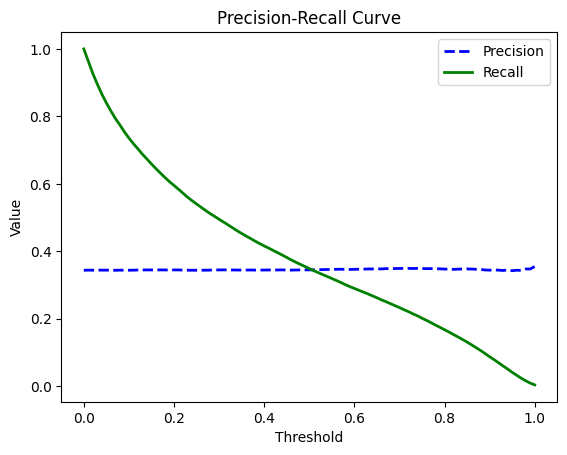

In [ ]:
y_scores_forest = y_probas_forest

MetricsManager.plot_precision_recall_vs_threshold(y_train, y_scores_forest)

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.datasets import load_iris
import numpy as np

# Suponiendo que tienes datos cargados en X_train y y_train
X_train, y_train = load_iris(return_X_y=True)

# Definir un modelo y un preprocesador (este es solo un ejemplo)
model = RandomForestClassifier()
preprocess = None  # Reemplaza esto con tu preprocesador real

# Configurar el pipeline
full_pipeline = Pipeline(steps=[('preprocessor', preprocess),
                                ('classifier', model)])

def objective(trial):
    # Definir los espacios de búsqueda de los hiperparámetros
    param = {
        'classifier__n_estimators': trial.suggest_int('classifier__n_estimators', 50, 200),
        'classifier__max_depth': trial.suggest_int('classifier__max_depth', 3, 15),
        # Añade aquí más hiperparámetros para optimizar
    }

    # Seteamos los hiperparámetros en el pipeline
    full_pipeline.set_params(**param)

    # Realizamos validación cruzada
    scores = cross_val_score(full_pipeline, X_train, y_train, 
                             scoring='roc_auc', cv=KFold(n_splits=3, shuffle=True, random_state=3565436))

    # Optuna minimiza, por lo que devolvemos el negativo del roc_auc promedio
    return -np.mean(scores)

# Creación del estudio de Optuna que optimizará la función objetivo
study = optuna.create_study(direction='minimize')

study.optimize(objective, n_trials=100, n_jobs=12)

print('Number of finished trials:', len(study.trials))
print('Best trial:')
trial = study.best_trial

print('  Value: {}'.format(-trial.value))
print('  Params: ')
for key, value in trial.params.items():
    print(f'    {key}: {value}')


In [ ]:
from sklearn.metrics import f1_score, make_scorer

# Definir una función de puntuación F1 para usar en la validación cruzada
def f1_scorer(y_true, y_pred):
    # Calcula el F1-score
    score = f1_score(y_true, y_pred, average='macro')  # 'macro' para multiclase sin ponderar
    return score

# Crear un scorer utilizando make_scorer de scikit-learn
custom_f1_scorer = make_scorer(f1_scorer)


In [ ]:
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.datasets import load_iris
import numpy as np


def objective(trial):
    # Definir los espacios de búsqueda de los hiperparámetros
    param = {
        'classifier__n_estimators': trial.suggest_int('classifier__n_estimators', 900, 1300),
        'classifier__max_depth': trial.suggest_int('classifier__max_depth', 40,60),
        'classifier__min_samples_split': trial.suggest_int('classifier__min_samples_split', 3,6),
        'classifier__min_samples_leaf': trial.suggest_int('classifier__min_samples_leaf', 2,5),

        # Puedes añadir más parámetros aquí
    }

    # Setear los hiperparámetros en el pipeline
    full_pipeline.set_params(**param)

    # Realizar validación cruzada utilizando el scorer personalizado de F1
    scores = cross_val_score(full_pipeline, X_train, y_train, scoring=custom_f1_scorer, cv=KFold(n_splits=3, shuffle=True, random_state=3565436))

    # Optuna minimiza, por lo que devolvemos el negativo del F1-score promedio
    return -np.mean(scores)

# Crear y ejecutar el estudio de Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, n_jobs=10)

# Imprimir los resultados
print('Number of finished trials:', len(study.trials))
print('Best trial:')
trial = study.best_trial
print('  Value: {}'.format(-trial.value))
for key, value in trial.params.items():
    print(f'    {key}: {value}')

# 'classifier__n_estimators': 1000, 'classifier__min_samples_split': 4, 'classifier__min_samples_leaf': 3, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 50


[I 2024-04-14 12:04:40,236] A new study created in memory with name: no-name-0d0a311f-896b-4cac-8dd7-8f03784a1c33
[I 2024-04-14 12:34:31,654] Trial 2 finished with value: -0.8186433801873122 and parameters: {'classifier__n_estimators': 979, 'classifier__max_depth': 41, 'classifier__min_samples_split': 6, 'classifier__min_samples_leaf': 3}. Best is trial 2 with value: -0.8186433801873122.
[I 2024-04-14 12:34:49,391] Trial 1 finished with value: -0.8186433801873122 and parameters: {'classifier__n_estimators': 1131, 'classifier__max_depth': 47, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 3}. Best is trial 2 with value: -0.8186433801873122.
[I 2024-04-14 12:34:54,429] Trial 7 finished with value: -0.8186248825144672 and parameters: {'classifier__n_estimators': 1265, 'classifier__max_depth': 60, 'classifier__min_samples_split': 6, 'classifier__min_samples_leaf': 3}. Best is trial 2 with value: -0.8186433801873122.
[I 2024-04-14 12:35:03,058] Trial 6 finished with val

Number of finished trials: 100
Best trial:
  Value: 0.818765740686275
    classifier__n_estimators: 936
    classifier__max_depth: 40
    classifier__min_samples_split: 5
    classifier__min_samples_leaf: 4
